# Дифференцирование

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axhline.html#matplotlib.pyplot.axhline
* https://numpy.org/doc/stable/reference/generated/numpy.log1p.html#numpy.log1p
* https://docs.sympy.org/latest/tutorials/intro-tutorial/calculus.html
* https://en.wikipedia.org/wiki/Finite_difference
* https://pythonnumericalmethods.berkeley.edu/notebooks/chapter20.02-Finite-Difference-Approximating-Derivatives.html
* https://en.wikipedia.org/wiki/Gradient_descent
* https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html
* https://zhang-yang.medium.com/the-gradient-argument-in-pytorchs-backward-function-explained-by-examples-68f266950c29

## Задачи для совместного разбора

1\. Дана функция $f(x) = x^2$. Найдите производную этой функции различными способами

## Задачи для самостоятельного решения

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import torch as th

<p class="task" id="1"></p>

1\. Дана функция $f(x)$. Найдите (аналитически) производную данной функции $f'(x)$ и реализуйте две этих функции. Постройте в одной системе координат графики $f(x)$, $f'(x)$ и $g(x) = 0$ на отрезке [1, 10]. Изобразите графики различными цветами и включите сетку.

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

- [ ] Проверено на семинаре

In [18]:
def f(x):
  return np.sin(x) / (np.log(x) + 1)

def df(x):
  return (np.cos(x) * (np.log(x) + 1) - np.sin(x) * (1/x)) / (np.log(x) + 1)**2

def g(x):
  return x*0

In [19]:
x_range = np.linspace(1, 11, 1000)

<function matplotlib.pyplot.show(close=None, block=None)>

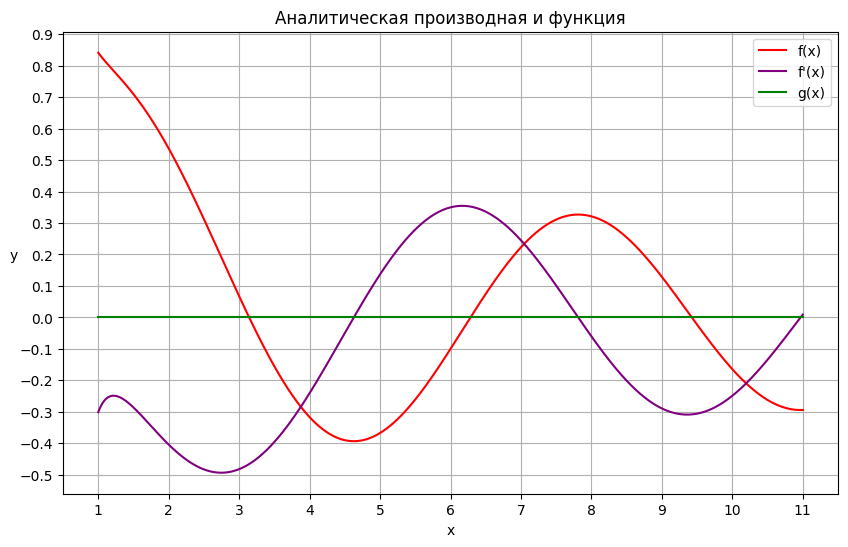

In [20]:
fig = plt.figure(figsize=(10, 6))
plt.plot(x_range, f(x_range), c='red', label='f(x)')
plt.plot(x_range, df(x_range), c='purple', label="f'(x)")
plt.plot(x_range, g(x_range), c='green', label='g(x)')
plt.xlabel('x')
plt.ylabel('y', rotation=0)
plt.locator_params(axis='both', nbins=20)
plt.title('Аналитическая производная и функция')
plt.grid(True)
plt.legend()
plt.show

<p class="task" id="2"></p>

2\. Дана функция $f(x)$. Найдите (численно) производную данной функции $f'(x)$ на отрезке [1, 10]. Постройте в одной системе координат график $f(x)$, $f'(x)$ и $g(x) = 0$. Изобразите графики различными цветами и включите сетку.

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

- [ ] Проверено на семинаре

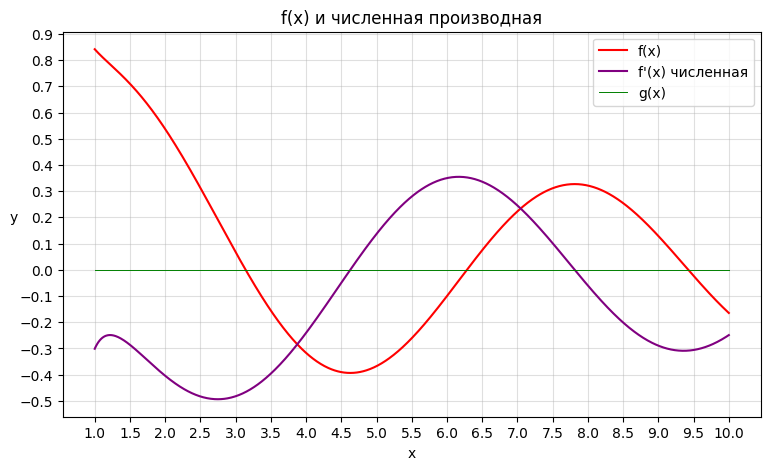

In [21]:
x = np.linspace(1, 10, 1000)
h = x[1] - x[0]
def df(x):
  return (f(x + h) - f(x - h)) / (2 * h)

plt.figure(figsize=(9, 5))
plt.plot(x, f(x), 'red',  label='f(x)')
plt.plot(x, df(x), 'purple', label="f'(x) численная")
plt.plot(x, g(x), 'green', lw=0.7, label='g(x)')
plt.xlabel('x')
plt.ylabel('y', rotation=0)
plt.locator_params(axis='both', nbins=20)
plt.grid(True, alpha=0.4)
plt.legend()
plt.title("f(x) и численная производная")
plt.show()

<p class="task" id="3"></p>

3\. Найдите локальный минимум функции $f(x)$ при помощи метода градиентного спуска. В качестве начальной точки используйте $x_0 = 4$. Найдите локальный максимум этой же функции, используя в качестве начальной точки $x_0'=9$.

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

- [ ] Проверено на семинаре

In [22]:
def gradient(x0, ascent: bool, lr=0.4, tol=1e-8, max_iter=10000):
  x = x0
  for i in range(1, max_iter):
    grad = df(x) #Изменение функции на значение производной
    if not ascent:
      x -= lr * grad #В зависимости от величины df будет уменьшаться dx
    else:
      x += lr * grad #В зависимости от величины df будет увеличиваться dx
    if lr * grad > tol:
      break
  return x, f(x)


In [23]:
x_min, f_min = gradient(4, False)
print(f'x_min: {x_min:.4}\nf_min: {f_min:.4}')

x_min: 4.627
f_min: -0.3935


In [24]:
x_max, f_max = gradient(9, True)
print(f'x_max: {x_max:.4}\nf_max: {f_max:.4}')

x_max: 7.812
f_max: 0.327


<p class="task" id="4"></p>

4\. Дана функция $f(x)$. Найдите (используя возможности по автоматическому дифференцированию пакета `torch`) производную данной функции $f'(x)$ на отрезке [0, 10]. Постройте в одной системе координат график $f(x)$, $f'(x)$ и $g(x) = 0$ на полуинтервале (0, 10]. Изобразите графики различными цветами и включите сетку.

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

- [ ] Проверено на семинаре

In [25]:
x = th.tensor(x, dtype=th.float64, requires_grad=True)

f = th.sin(x) / (th.log(x) + 1)
f.sum().backward()               # считаем градиент по всем точкам сразу
fp_torch = x.grad.numpy()

/tmp/ipython-input-54346/3729367204.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plt.plot(x.detach().numpy(), th.tensor(g(x)).detach().numpy(), 'green', label='g(x)')


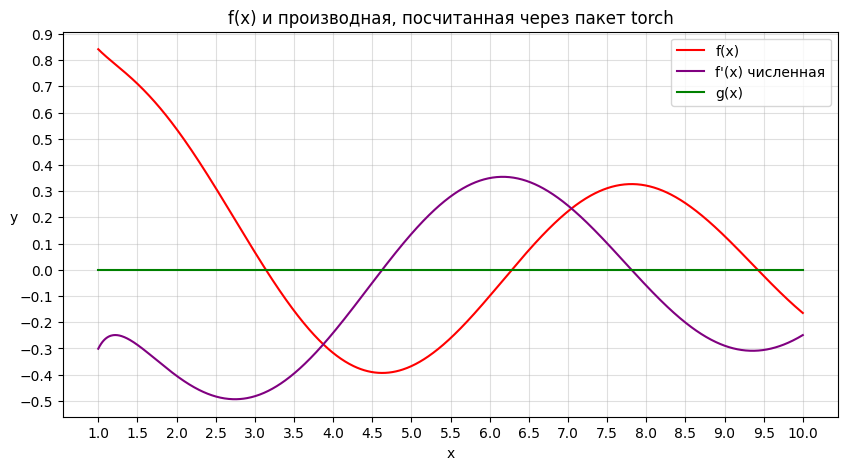

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(x.detach().numpy(), f.detach().numpy(), 'red',  label='f(x)')
plt.plot(x.detach().numpy(), th.tensor(fp_torch).detach().numpy(), 'purple', label="f'(x) численная")
plt.plot(x.detach().numpy(), th.tensor(g(x)).detach().numpy(), 'green', label='g(x)')
plt.xlabel('x')
plt.ylabel('y', rotation=0)
plt.locator_params(axis='both', nbins=20)
plt.grid(True, alpha=0.4)
plt.legend()
plt.title("f(x) и производная, посчитанная через пакет torch")
plt.show()

<p class="task" id="5"></p>

5\. Дана функция $f(x)$. Найдите производную данной функции $f'(x)$ на отрезке [0, 10] при помощи формулы производной сложной функции. На этом же отрезке найдите, используя возможности по автоматическому дифференцированию пакета `torch`. Сравните результаты.

$$f(x) = sin(cos(x))$$

- [ ] Проверено на семинаре

In [33]:
def f(x: th.Tensor) -> th.Tensor:
    return th.sin(th.cos(x))

def g(x: th.Tensor) -> th.Tensor:
    return th.cos(x)

def dfdg(x: th.Tensor) -> th.Tensor:
    return th.cos(th.cos(x))

def dgdx(x: th.Tensor) -> th.Tensor:
    return -th.sin(x)

def dfdx(x: th.Tensor) -> th.Tensor:
    return dfdg(x) * dgdx(x)

In [34]:
x = th.tensor(x, dtype=th.float64, requires_grad=True)
f(x).sum().backward()
fp_th = x.grad.numpy()

/tmp/ipython-input-54346/4113112976.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = th.tensor(x, dtype=th.float64, requires_grad=True)


In [35]:
f(x)[:5]

tensor([0.5144, 0.5079, 0.5013, 0.4946, 0.4879], dtype=torch.float64,
       grad_fn=<SliceBackward0>)

/tmp/ipython-input-54346/1754427877.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plt.plot(x.detach().numpy(), th.tensor(g(x)).detach().numpy(), 'green', label='g(x) = cos(x)')


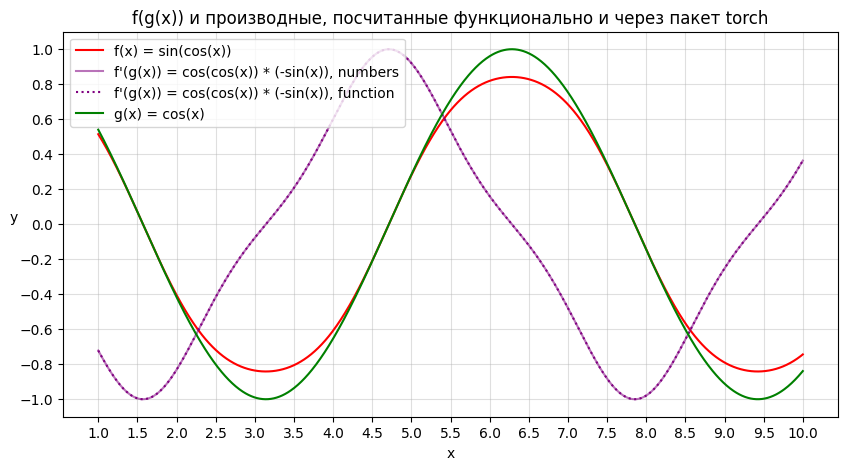

In [41]:
x1 = np.linspace(1, 10, 10)
x1 = th.tensor(x1, dtype=th.float64, requires_grad=True)

plt.figure(figsize=(10, 5))
plt.plot(x.detach().numpy(), f(x).detach().numpy(), 'red',  label='f(x) = sin(cos(x))')
plt.plot(x.detach().numpy(), th.tensor(fp_th).detach().numpy(), 'purple', alpha=0.55, label="f'(g(x)) = cos(cos(x)) * (-sin(x)), numbers")
plt.plot(x.detach().numpy(), dfdx(x).detach().numpy(), 'purple', linestyle=':', label="f'(g(x)) = cos(cos(x)) * (-sin(x)), function")
plt.plot(x.detach().numpy(), th.tensor(g(x)).detach().numpy(), 'green', label='g(x) = cos(x)')
plt.xlabel('x')
plt.ylabel('y', rotation=0)
plt.locator_params(axis='both', nbins=20)
plt.grid(True, alpha=0.4)
plt.legend()
plt.title("f(g(x)) и производные, посчитанные функционально и через пакет torch")
plt.show()